<a href="https://colab.research.google.com/github/katezotko/Sales-Analytics/blob/main/Portfolio_Project_Cheholia%20Kateryna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from scipy import stats

auth.authenticate_user()

client = bigquery.Client(project="data-analytics-mate")



In [ ]:
query = """
select
s.date,
s.ga_session_id,
sp.continent,
sp.country,
sp.device,
sp.browser,
sp.mobile_model_name,
sp.operating_system,
sp.language,
sp.medium as traffic_source,
sp.channel as traffic_channel,
ac.id as registered_user,
ac.is_verified as user_confirmed,
ac.is_unsubscribed as user_unsubscribed,
p.category,
p.name as product_name,
p.price,
p.short_description

from `data-analytics-mate.DA.session` s
left join `data-analytics-mate.DA.session_params` sp
on s.ga_session_id = sp.ga_session_id
left join `data-analytics-mate.DA.account_session` acs
on s.ga_session_id = acs.ga_session_id
left join`data-analytics-mate.DA.account` ac
on acs.account_id = ac.id
left join  `data-analytics-mate.DA.order` o
on s.ga_session_id = o.ga_session_id
left join  `data-analytics-mate.DA.product` p
on o.item_id = p.item_id
"""
query_job = client.query(query)

result = query_job.to_dataframe(create_bqstorage_client=False)

result.head()




,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,traffic_channel,registered_user,user_confirmed,user_unsubscribed,category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
result.info()
# Calculate unique values
unique_sessions = result['ga_session_id'].nunique()
print(f"Number of unique sessions: {unique_sessions}")

# Determining the time period covered by the dataset
min_date = result['date'].min()
max_date = result['date'].max()
print(f"Time period in the dataset: {min_date} to {max_date}")

# Identifying missing values across columns
missing_data = result.isna().sum().sort_values(ascending=False)
print(missing_data)

# FIX: Use 'product_name' to identify orders since 'item_id' is not in the DataFrame
sessions_with_orders = result['ga_session_id'][result['product_name'].notna()].nunique()
conversion = (sessions_with_orders / unique_sessions) * 100
print(f"Converting sessions into orders: {conversion:.2f}%")

# Top 5 most popular products by order count
print(result['product_name'].value_counts().head(5))

# 1. Filter rows where an order was actually placed
orders_data = result[result['product_name'].notna()]
# 2. Group by session ID and count the number of items in each order
items_per_order = orders_data.groupby('ga_session_id')['product_name'].count()
# 3. Calculate the average number of items per order
average_items = items_per_order.mean()
print(f"Average number of items per order: {average_items:.2f}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  traffic_channel    349545 non-null  object 
 11  registered_user    27945 non-null   Int64  
 12  user_confirmed     27945 non-null   Int64  
 13  user_unsubscribed  27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  product_name       33538 non-null   object 
 16  pr

### Dataset Summary & Insights

* **Dataset Overview:** The dataset consists of **349545 entries** and **18 columns** (4 integer, 1 date, 1 float, and 12 object columns).
* **Time Period Covered:** The analysis covers exactly 3 months, from **November 1, 2020 to January 31, 2021**.
* **Traffic & Volume:** A total of **349545 unique sessions** were recorded, meaning each row in the dataset represents an individual session.

### Key Business Metrics
* **Session-to-Order Conversion Rate:** **9.59%** of all sessions result in a successful order.
* **Average Items per Order:** On average, customers purchase exactly **one item per order**, indicating that multi-item shopping carts are rare.
* **Top 5 Best-Selling Products:**
  1. BESTÅ (1,257 orders)
  2. GRÖNLID (915 orders)
  3. TROFAST (813 orders)
  4. IVAR (754 orders)
  5. VIMLE (724 orders)

### Data Quality & Missing Values
There is a high volume of missing (`NaN`) values in user-related columns (321,600 missing) and product-related columns (316,007 missing). This occurs naturally due to the **LEFT JOIN** configuration: the majority of website visitors navigate the platform anonymously without logging in, and look through products without making a purchase.

**Determine which continents and countries generate the highest sales for the company**

In [ ]:
# 1. Filter only completed orders
sales_only = result[result['price'].notna()]

# 2. Top 3 continents by number of orders and total revenue
top_continents = sales_only.groupby('continent').agg(order_count=('ga_session_id', 'count'), total_revenue=('price', 'sum')).sort_values(by='total_revenue', ascending=False).head(3)
print("TOP 3 CONTINENTS")
print(top_continents)


# 3. Top 5 countries by number of orders and total revenue
top_countries = sales_only.groupby('country').agg(
    order_count=('ga_session_id', 'count'),
    total_revenue=('price', 'sum')
).sort_values(by='total_revenue', ascending=False).head(5)

print("\nTOP 5 COUNTRIES")
print(top_countries)

TOP 3 CONTINENTS
           order_count  total_revenue
continent                            
Americas         18553     17665280.0
Asia              7950      7601298.3
Europe            6261      5934624.2

TOP 5 COUNTRIES
                order_count  total_revenue
country                                   
United States         14673     13943553.9
India                  3029      2809762.0
Canada                 2560      2437921.0
United Kingdom         1029       938317.9
France                  678       710692.8


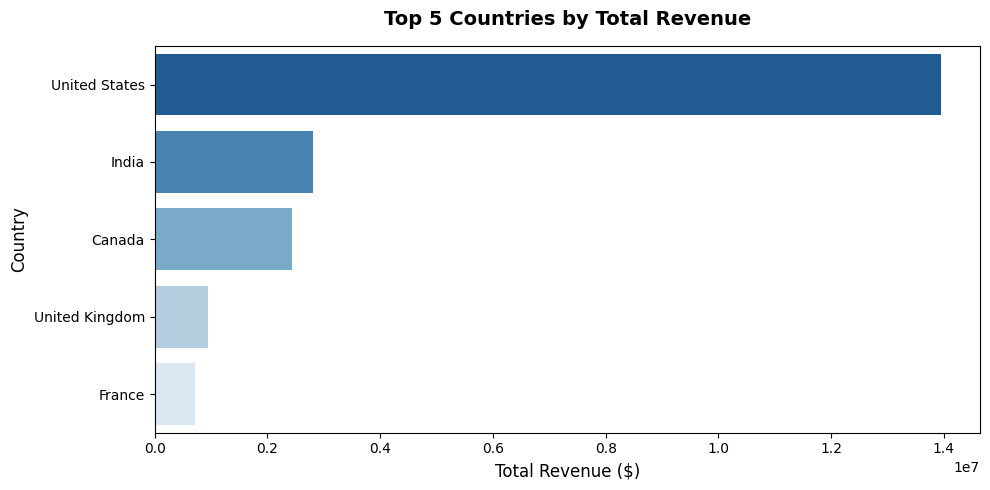

In [ ]:

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries['total_revenue'], y=top_countries.index, hue=top_countries.index,palette="Blues_r",legend=False)
plt.title('Top 5 Countries by Total Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

The **American market** generates the highest revenue for the company, accounting for 17.67M\$ and 18553 orders, making it the most important sales region.
**Asia** and **Europe** rank second and third, generating 7.60M\$ and 5.93M\$ in revenue, respectively.
At the country level, the United States is the dominant market, contributing 13.94M\$ in revenue and 14673 orders, significantly outperforming all other countries.
**India** and **Canada** are the next strongest markets, with revenues of 2.81M\$ and 2.44M\$, indicating strong growth potential.

The visualization reveals a substantial revenue gap between the United States and the remaining countries, highlighting the company's strong reliance on the U.S. market.

Strategic Recommendations: To reduce market concentration risk and support sustainable growth, the company could focus on expanding its presence in Asia and Europe, particularly in high-performing countries such as India.

The analysis shows that the company's sales are heavily concentrated in the United States, while India and Canada represent promising opportunities for future expansion.

**Analyze sales performance by traffic source**

In [ ]:
# Calculate revenue generated by each traffic channel
traffic_revenue = sales_only.groupby('traffic_channel')['price'].sum()

# Convert revenue values into percentages of total revenue
traffic_percentage = (traffic_revenue / traffic_revenue.sum()) * 100
traffic_percentage = traffic_percentage.sort_values(ascending=False)

print("REVENUE BY TRAFFIC CHANNEL (%)")
print(traffic_percentage.round(2))

REVENUE BY TRAFFIC CHANNEL (%)
traffic_channel
Organic Search    35.76
Paid Search       26.62
Direct            23.44
Social Search      7.92
Undefined          6.26
Name: price, dtype: float64


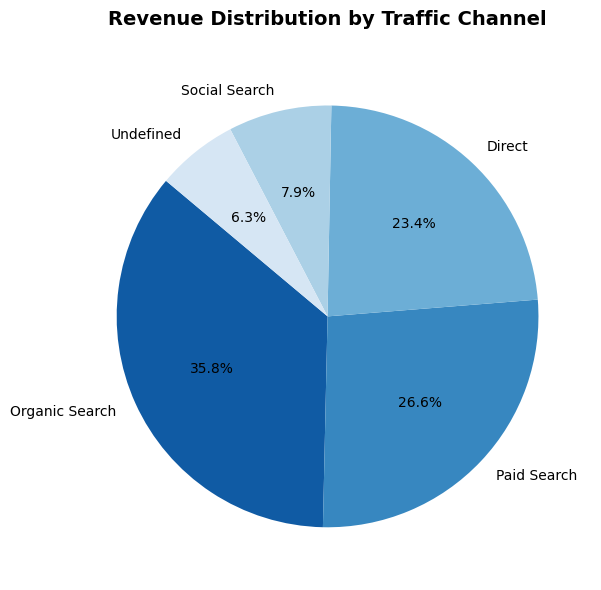

In [ ]:
plt.figure(figsize=(8, 6))
colors = sns.color_palette("Blues_r", n_colors=len(traffic_percentage))
plt.pie(traffic_percentage, labels=traffic_percentage.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Revenue Distribution by Traffic Channel', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

The analysis of revenue distribution by traffic channel shows that **Organic Search** is the most effective sales source, generating 35.76% of the company's total revenue. This highlights the importance of organic search visibility and SEO efforts in attracting customers.

**Paid Search** ranks second with 26.62% of total revenue, demonstrating the strong performance of paid advertising campaigns.

The **Direct** channel contributes 23.44% of revenue, which may indicate strong brand awareness and a loyal customer base.

**Social Search** accounts for only 7.92% of total revenue, suggesting that social media channels have a smaller impact on revenue generation compared to search-driven traffic.

The **Undefined** category contributes 6.26% of revenue, indicating potential opportunities to improve traffic source tracking and attribution.

Overall, the results show that search-related channels (organic and paid) are the primary drivers of revenue, collectively generating more than 62% of the company's total sales revenue.

**Calculate the percentage of registered users who confirmed their address and unsubscribed from the newsletter**

In [ ]:
# 1. Keep only unique registered users
users = result[result['registered_user'].notna()].drop_duplicates(subset=['registered_user'])

# 2. Calculate the percentage of users who confirmed their email address
confirmed_pct = (users['user_confirmed'].sum() / len(users)) * 100

# 3. Calculate the percentage of users who unsubscribed from the newsletter
unsubscribed_pct = (users['user_unsubscribed'].sum() / len(users)) * 100

print(f"Percentage of users who confirmed email: {confirmed_pct:.2f}%")
print(f"Percentage of users who unsubscribed: {unsubscribed_pct:.2f}%")

Percentage of users who confirmed email: 71.70%
Percentage of users who unsubscribed: 16.94%


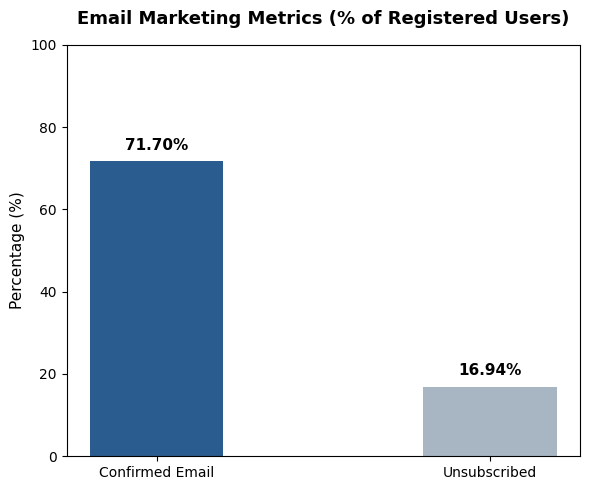

In [ ]:
plt.figure(figsize=(6, 5))
metrics = ['Confirmed Email', 'Unsubscribed']
values = [confirmed_pct, unsubscribed_pct]
bars = plt.bar(metrics, values, color=['#2b5c8f', '#a8b6c4'], width=0.4)
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 2,
        f"{yval:.2f}%",
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )
plt.title('Email Marketing Metrics (% of Registered Users)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Percentage (%)', fontsize=11)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

The analysis of registered user behavior shows that 71.70% of users **Confirmed** their email addresses. This indicates a high level of user engagement and an effective registration and account verification process.

Only 16.94% of users **Unsubscribed** from the email newsletter, suggesting a relatively low subscriber churn rate and a positive response to the company's marketing communications.

The substantial gap between the percentage of confirmed users and the unsubscribe rate indicates that most registered customers remain willing to engage with the company through email communication.

Email marketing remains an effective communication channel, as a large proportion of users confirm their email addresses while the unsubscribe rate remains relatively low.

# Sales Dynamics Analysis
We will analyze sales dynamics to identify general trends, seasonality, as well as the efficiency of different regions, traffic channels, and devices.

**Total Sales Dynamics & Seasonality Analysis**

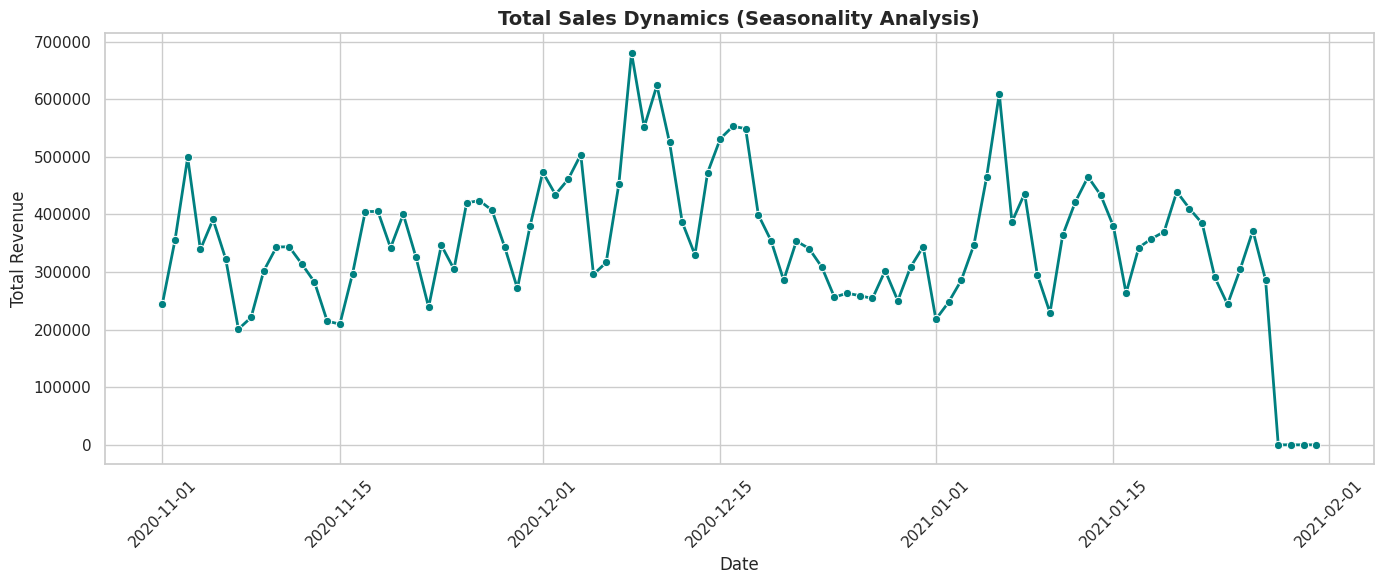

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

plt.figure()
daily_sales = result.groupby('date')['price'].sum().reset_index()

sns.lineplot(data=daily_sales, x='date', y='price', marker='o', color='teal', linewidth=2)
plt.title('Total Sales Dynamics (Seasonality Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Based on the visualized daily sales data from November 2020 to January 2021, we can draw several key conclusions regarding the business performance and customer behavior:

**Cyclical Weekly Seasonality:** The chart clearly displays regular, recurring ups and downs. Sales consistently peak and drop within 7-day intervals. This pattern strongly indicates **weekly seasonality**, where transaction volumes likely surge during weekends or specific weekdays and drop during the remaining days.

**Holiday Peaks & Trends:** A significant upward trend is visible starting from late November, reaching its absolute peak in the first half of December(surpassing 680000 in total revenue). This correlates perfectly with the pre-holiday shopping season (Black Friday aftermath and Christmas preparations).
A noticeable drop in revenue occurs right around late December (Christmas/New Year holidays), followed by a sharp but short-term post-holiday recovery spike in early January 2021.

**Sales Dynamics by Continent (Americas, Asia, Europe)**

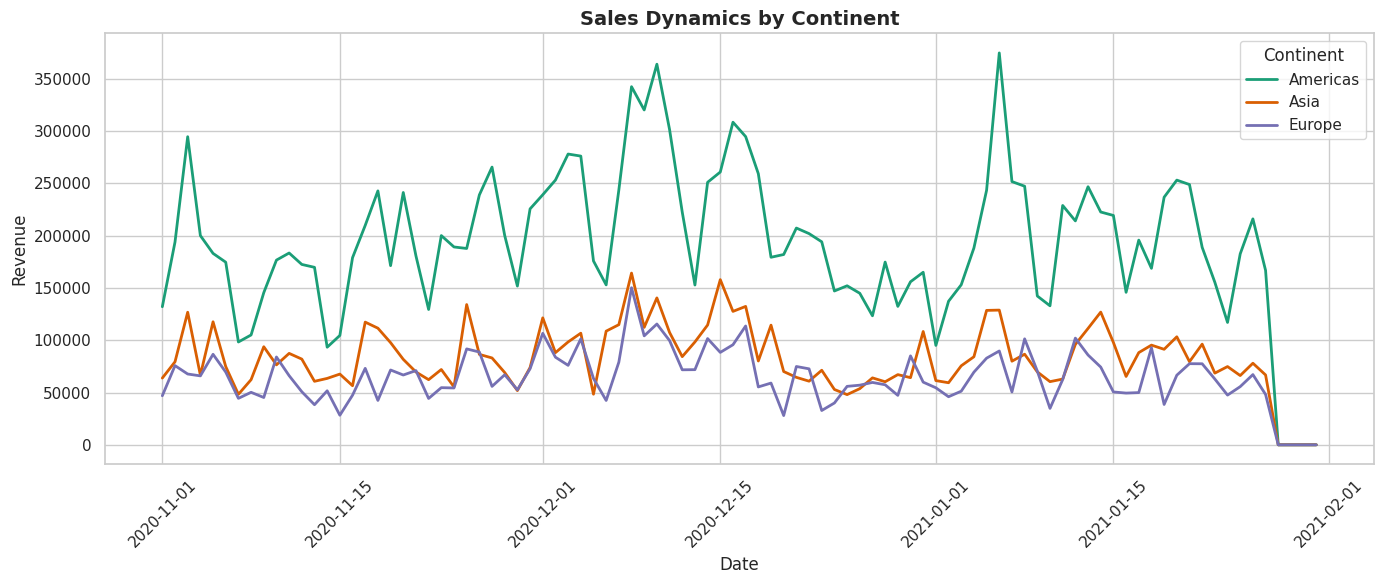

In [ ]:
plt.figure()
# 1. Filtering only the requested continents
continents_list = ['Americas', 'Asia', 'Europe']
continents = result[result['continent'].isin(continents_list)]

# 2. Aggregating sales by date and continent
geo_sales = continents.groupby(['date', 'continent'])['price'].sum().reset_index()

sns.lineplot(data=geo_sales, x='date', y='price', hue='continent', palette='Dark2', linewidth=2)
plt.title('Sales Dynamics by Continent', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Continent')
plt.tight_layout()
plt.show()



The chart illustrates the breakdown of revenue across three key regions: the Americas, Asia, and Europe. Several critical insights can be extracted from this visualization:

**Dominant Market:** The **Americas** market is the undisputed leader, consistently generating the highest revenue throughout the entire observed period. Its daily sales frequently fluctuate between 250000\$ and 350000\$, making it the primary driver of the company's overall financial performance.

**Secondary Markets:** Both **Asia** and **Europe** perform at a significantly lower revenue tier compared to the Americas, generally ranging from 50000\$ to 150000\$.
  * **Asia** slightly outperforms Europe during most of November and December, showing higher volatility and sharper short-term peaks.
  * **Europe** demonstrates a more stable, less volatile trend but consistently sits at the bottom in terms of total daily volume.
**Synchronized Holiday Trends:** Interestingly, all three regions exhibit highly synchronized behavior during major events. The pre-holiday spike in early December and the sharp post-New Year recovery in early January are visible across all continents simultaneously. This suggests that the product or promotional campaigns have a unified global appeal rather than being region-specific.


**Sales Dynamics by Traffic Channels**

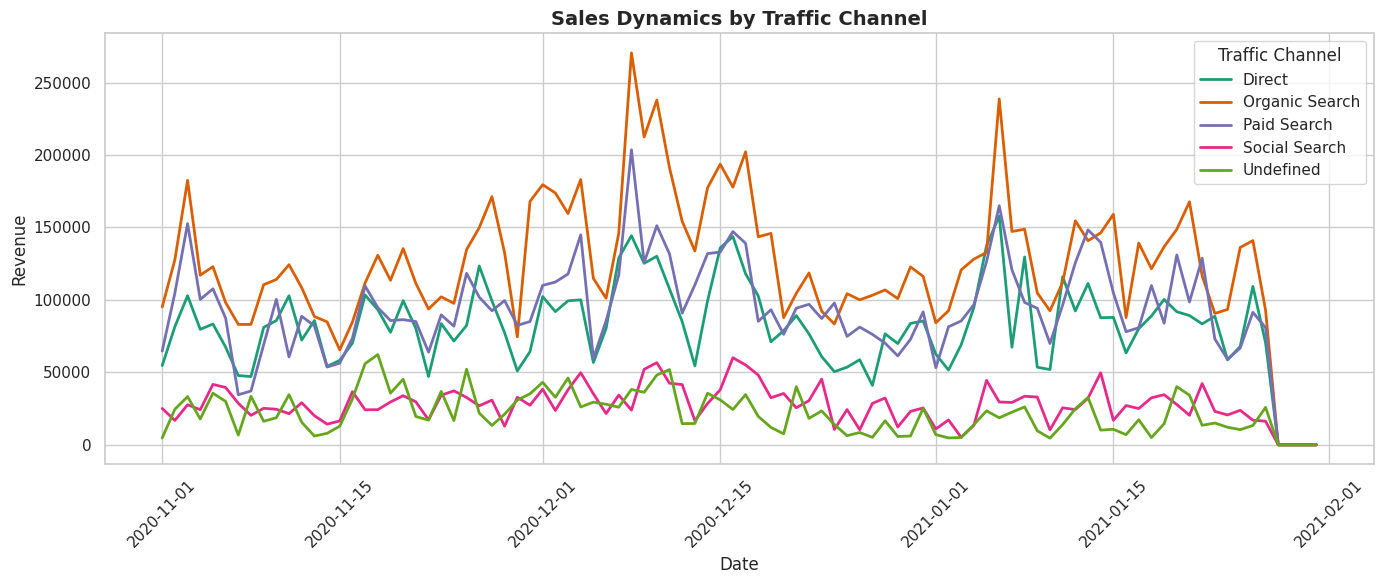

In [ ]:
plt.figure()
channel_sales = result.groupby(['date', 'traffic_channel'])['price'].sum().reset_index()

sns.lineplot(data=channel_sales, x='date', y='price', hue='traffic_channel', palette='Dark2', linewidth=2)
plt.title('Sales Dynamics by Traffic Channel', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Traffic Channel')
plt.tight_layout()
plt.show()

 **Organic Search** is the absolute powerhouse for revenue generation. It  captures the highest market share throughout the entire timeline, peaking at over 250000\$ in early December. This reflects strong brand authority, solid SEO execution, and high intent among inbound organic visitors.

 **Paid Search** and **Direct** traffic channels exhibit heavily correlated performance, generally tracking tightly together in the 50000\$ to 150,000\$ revenue range. Paid Search scales up to match or closely trail Organic Search, proving that ad spend campaigns were highly effective during peak promotional events.

**Social Search** and **Undefined** channels remain consistently at the bottom tier, rarely breaking past 50000\$ daily revenue. While Social Search shows slight lifts during the December holiday season, it remains an underutilized.

**Sales Dynamics by Device Types**

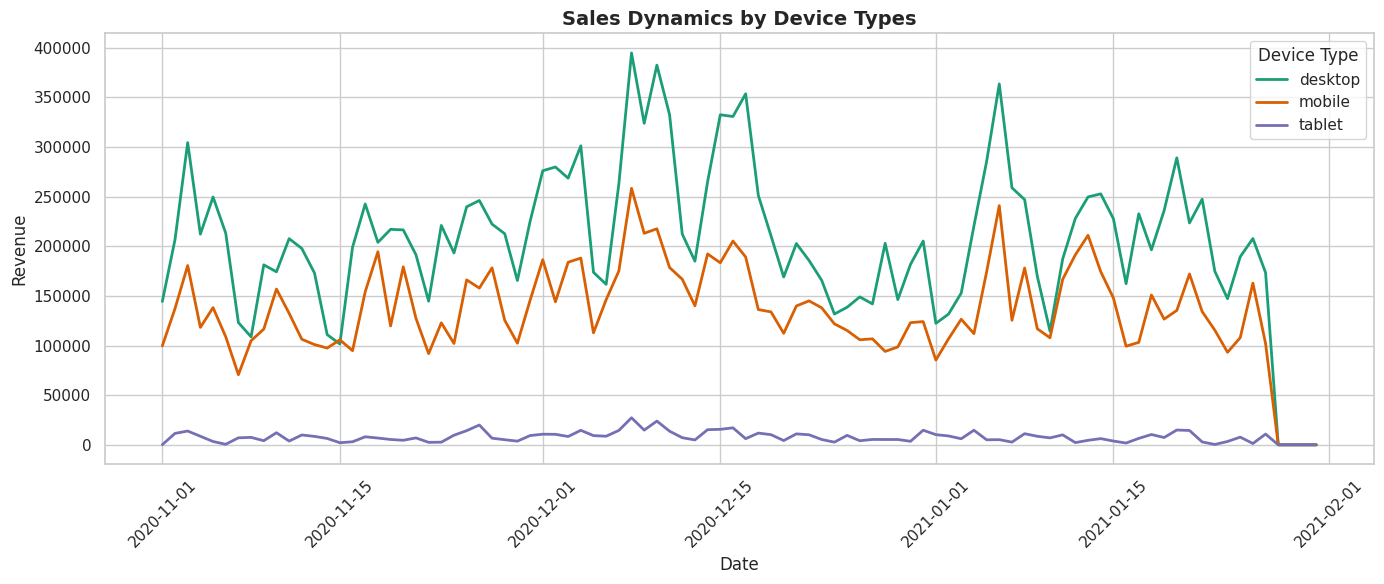

In [ ]:
plt.figure()
device_sales = result.groupby(['date', 'device'])['price'].sum().reset_index()

sns.lineplot(data=device_sales, x='date', y='price', hue='device', palette='Dark2', linewidth=2)
plt.title('Sales Dynamics by Device Types', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Device Type')
plt.tight_layout()
plt.show()

 **Desktop** users generate the highest daily volume, frequently ranging between 150000\$ and 350000\$. This dominance suggests that while users might browse on other platforms, they heavily prefer the security, stability, or ease of navigation of a desktop environment when finalizing a transaction.

 **Mobile** traffic represents a strong and highly reactive secondary tier, generally tracking between 100000\$ and 200000\$ in revenue. It mirrors the exact behavioral shifts of desktop, peaking sharply during the pre-holiday season in early December.

**Tablet** devices represent a smoll fraction of overall revenue, consistently flattening near the bottom axis and rarely exceeding 25000\$.

Optimization resources should be heavily prioritized toward desktop and mobile rather than tablet-specific improvements.

**Сonstruction of pivot tables for detailed cross-analysis of the data set**

**1. Session Count by Traffic Channels and Device Types**

In [ ]:
# Filtering out undefined/missing values as requested
filtered_table1 = result[result['traffic_channel'].notna() & result['device'].notna() & (~result['traffic_channel'].isin(['Undefined', '(not set)'])) & (~result['device'].isin(['Undefined', '(not set)']))]

pivot_sessions = filtered_table1.pivot_table(
    index='traffic_channel',
    columns='device',
    values='ga_session_id',
    aggfunc='nunique'
)

print("Session Count by Traffic Channel and Device Type")
display(pivot_sessions)

Session Count by Traffic Channel and Device Type


device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638


**2. Total Sales by Product Categories (Top 10) and Countries (Top 5)**

In [ ]:
#Identify Top 10 categories by total revenue
top_categories = result.groupby('category')['price'].sum().nlargest(10).index

#Identify Top 5 countries by total revenue
top_countries = result.groupby('country')['price'].sum().nlargest(5).index

#Filter the main DataFrame based on Top 10 categories and Top 5 countries
filtered_table2 = result[result['category'].isin(top_categories) & result['country'].isin(top_countries)]

pivot_sales = filtered_table2.pivot_table(
    index='category',
    columns='country',
    values='price',
    aggfunc='sum'
)

print("Total Sales by Product Categories (Top 10) and Countries (Top 5)")
display(pivot_sales)

Total Sales by Product Categories (Top 10) and Countries (Top 5)


country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


**3. Total Revenue and Orders by Traffic Source**

In [ ]:
pivot_table3 = result.groupby('traffic_source').agg(
    total_revenue=('price', 'sum'),
    total_orders=('ga_session_id', 'nunique')
).sort_values(by='total_revenue', ascending=False).head(10)

print("Custom Table: Top 10 Traffic Sources by Revenue and Orders")
display(pivot_table3)

Custom Table: Top 10 Traffic Sources by Revenue and Orders


,total_revenue,total_orders
traffic_source,,
organic,10935239.9,119024
(none),7494923.4,81382
referral,5641855.2,61437
<Other>,4491351.1,50593
(data deleted),2041921.0,21859
cpc,1366440.5,15250


Cross-channel and cross-device analysis highlights **Organic Search** as the primary source of revenue across all platforms, while **Desktop** remains the highest-converting interface. This suggests that marketing efforts should continue to focus on simplifying the checkout process on desktops.

The distribution of product categories in the top 5 countries clearly indicates which products generate the most revenue in key regional markets. This allows for more targeted local advertising campaigns and more effective inventory management.


**Statistacal relationship analysis**

**Correlation Between Session Count and Total Sales by Date**

Correlation Between Sessions and Total Sales
Pearson Correlation Coefficient: 0.7911
P-value: 6.4835e-21
Result: Statistically significant (p < 0.05). There is a reliable correlation.


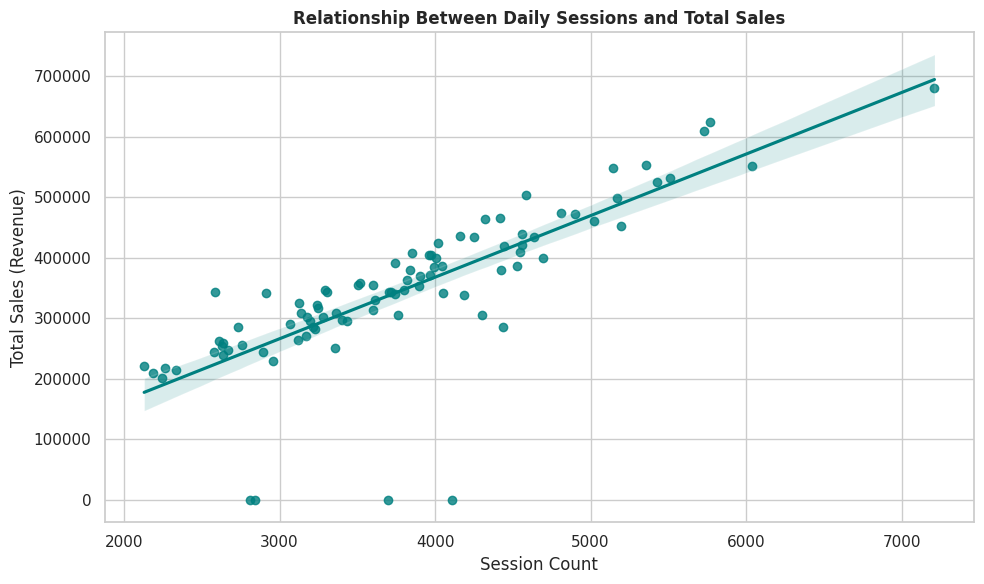

In [ ]:
# Grouping by date to calculate unique sessions and total revenue
daily_metrics = result.groupby('date').agg(session_count=('ga_session_id', 'nunique'),total_sales=('price', 'sum')).reset_index()

# Calculating Pearson correlation coefficient and p-value
corr_coef, p_value = stats.pearsonr(daily_metrics['session_count'], daily_metrics['total_sales'])

print("Correlation Between Sessions and Total Sales")
print(f"Pearson Correlation Coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.05:
    print("Result: Statistically significant (p < 0.05). There is a reliable correlation.")
else:
    print("Result: Not statistically significant (p >= 0.05). No reliable correlation.")

# Visualization: Scatter Plot with Regression Line
plt.figure(figsize=(10, 6))
sns.regplot(data=daily_metrics, x='session_count', y='total_sales', color='teal', marker='o')
plt.title('Relationship Between Daily Sessions and Total Sales', fontsize=12, fontweight='bold')
plt.xlabel('Session Count')
plt.ylabel('Total Sales (Revenue)')
plt.tight_layout()
plt.show()

Pearson Correlation Coefficient ($r$): 0.7911

Statistical Significance (P-value): $6.48 \times 10^{-21}$  < 0.05.There is a reliable correlation.

The analysis revealed a statistically significant and **strong positive relationship** between daily sessions and total sales revenue.

The extremely low p-value effectively rules out any possibility of this trend occurring due to random chance.

The scatter plot clearly visualizes this linear trend, showing that as session counts scale up, revenue grows proportionally along the regression line.

**Correlation Matrix Across Top 3 Continents**

In [ ]:
top_3_continents = ['Americas', 'Asia', 'Europe']
df_continents = result[result['continent'].isin(top_3_continents)]

# Pivoting data to get daily sales for each continent
continent_daily_sales = df_continents.pivot_table(
    index='date',
    columns='continent',
    values='price',
    aggfunc='sum'
).fillna(0)

print("Correlation Matrix Across Top 3 Continents")
continent_corr = continent_daily_sales.corr()
display(continent_corr)

Correlation Matrix Across Top 3 Continents


continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.792025,0.770586
Asia,0.792025,1.000000,0.768427
Europe,0.770586,0.768427,1.000000


**Americas vs Asia**: r = 0.7920 (Strong correlation)

**Americas vs Europe**: r = 0.7706 (Strong correlation)

**Asia vs Europe**: r = 0.7684 (Strong correlation)

The analysis of daily sales performance across the top 3 continents revealed a statistically strong positive linear relationship among all regions.

Correlation coefficients nearing 0.8 clearly indicate that revenue fluctuations across the Americas, Asia, and Europe occur in close synchronicity.

Effectively, when sales experience a surge in one region, they are highly likely to climb concurrently in the others.

**Correlation Matrix Across Traffic Channels**

In [ ]:
# Identifying top channels
df_channels = result[~result['traffic_channel'].isin(['Undefined', '(not set)'])]

channel_daily_sales = df_channels.pivot_table(
    index='date',
    columns='traffic_channel',
    values='price',
    aggfunc='sum'
).fillna(0)

print("Correlation Matrix Across Traffic Channels")
channel_corr = channel_daily_sales.corr()
display(channel_corr)

Correlation Matrix Across Traffic Channels


traffic_channel,Direct,Organic Search,Paid Search,Social Search
traffic_channel,,,,
Direct,1.000000,0.837833,0.814072,0.604060
Organic Search,0.837833,1.000000,0.870086,0.583117
Paid Search,0.814072,0.870086,1.000000,0.596428
Social Search,0.604060,0.583117,0.596428,1.000000


**Organic Search & Paid Search**: r = 0.8701 (Strong correlation)

**Direct & Organic Search**: r = 0.8378 (Strong correlation)

**Direct & Paid Search**: r = 0.8141 (Strong correlation)

**Social Search vs Others**: r ranges from 0.583 to 0.604 (Moderate correlation)

The daily sales analysis across different traffic sources revealed a very tight linear dependence between the primary acquisition channels.

The highest synchronicity is observed between **Organic Search** and **Paid Search** (r = 0.8701). This indicates that when sales from unpaid search results increase, revenue from paid ads grows almost symmetrically.

**Direct traffic** also shows a powerful bond with both search channels (r > 0.81). This pattern signals high brand equity and strong top-of-mind awareness: during high-activity days, users discover products via search engines while simultaneously coming back to the store directly via bookmarks or typed URLs.

**Social Search** operates somewhat autonomously (r ≈ 0.59). While it still aligns with overall demand trends, its performance is less tied to search behavior and is more likely driven by specific social media content schedules or highly focused targeting campaigns.

**Correlation Matrix Across Top 5 Product Categories**

In [ ]:
top_5_categories = result.groupby('category')['price'].sum().nlargest(5).index
df_categories = result[result['category'].isin(top_5_categories)]

category_daily_sales = df_categories.pivot_table(
    index='date',
    columns='category',
    values='price',
    aggfunc='sum'
).fillna(0)

print("Correlation Matrix Across Top 5 Product Categories")
category_corr = category_daily_sales.corr()
display(category_corr)

Correlation Matrix Across Top 5 Product Categories


category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
category,,,,,
Beds,1.000000,0.592913,0.514609,0.554500,0.535378
Bookcases & shelving units,0.592913,1.000000,0.539428,0.637090,0.666194
Cabinets & cupboards,0.514609,0.539428,1.000000,0.572870,0.657563
Chairs,0.554500,0.637090,0.572870,1.000000,0.578248
Sofas & armchairs,0.535378,0.666194,0.657563,0.578248,1.000000


**Sofas & armchairs & Bookcases & shelving units**: r = 0.6662 (Highest moderate correlation)

**Sofas & armchairs & Cabinets & cupboards**: r = 0.6576 (Moderately strong correlation)

**Chairs & Bookcases & shelving units**: r = 0.6371 (Moderately strong correlation)
**Beds & Cabinets & cupboards**: r = 0.5146 (Lowest moderate correlation)

The daily sales analysis of the top 5 furniture categories revealed a **consistent, moderately strong positive relationship** across all items. None of the top categories perform independently of the others.The tightest synchronicity is tied to **Sofas & armchairs and Bookcases & shelving units** (r = 0.6662). This indicates a consumer behavior trend where customers tend to renovate entire living spaces or home offices comprehensively, purchasing upholstered seating and shelving systems simultaneously during the same promotional windows or seasonal peaks. Because all correlation coefficients sit comfortably above the 0.5 threshold, it is clear that demand across these distinct groups shares common macroeconomic drivers - such as store-wide sales events, peak moving seasons, or holiday shopping cycles.

**Correlation Matrix Across Device Types**

In [ ]:
device_daily_sales = result.pivot_table(
    index='date',
    columns='device',
    values='price',
    aggfunc='sum'
).fillna(0)

print("Custom Analysis: Correlation Matrix Across Device Types")
device_corr = device_daily_sales.corr()
display(device_corr)

Custom Analysis: Correlation Matrix Across Device Types


device,desktop,mobile,tablet
device,,,
desktop,1.000000,0.873201,0.601354
mobile,0.873201,1.000000,0.567394
tablet,0.601354,0.567394,1.000000


**Desktop & Mobile**: r = 0.8732 (Very strong correlation)

**Desktop & Tablet**: r = 0.6014 (Moderate correlation)

**Mobile & Tablet**: r = 0.5674 (Moderate correlation)

The custom analysis of daily sales performance across different device form factors revealed an exceptionally tight linear relationship between **desktop and mobile** platforms (r = 0.8732). This indicates near-perfect synchronicity in purchasing behavior: on days when smartphone-driven revenue spikes, desktop-driven revenue climbs almost symmetrically.

**Tablets** exhibit a lower but still stable positive correlation with the other device groups (r  ≈  0.57 - 0.60). This is expected, as tablet traffic generally represents the smallest market share in modern e-commerce, yet it remains subject to the same overarching daily purchasing waves.

# Statistical Analysis of Differences Between Groups

**Daily Sales Analysis: Registered vs. Unregistered Users**

To analyze the distribution, we will use the Shapiro-Wilk test. If the data is normally distributed, we will apply the Student's t-test; otherwise, we will use the non-parametric Mann-Whitney U test.

Shapiro-Wilk p-value (Registered): 1.4817e-01
Shapiro-Wilk p-value (Unregistered): 1.2185e-03

Selected Statistical Test: Non-parametric Mann-Whitney U Test
Test Statistic: 360.0000, p-value: 8.3795e-27
Conclusion: The difference is STATISTICALLY SIGNIFICANT (p < 0.05).


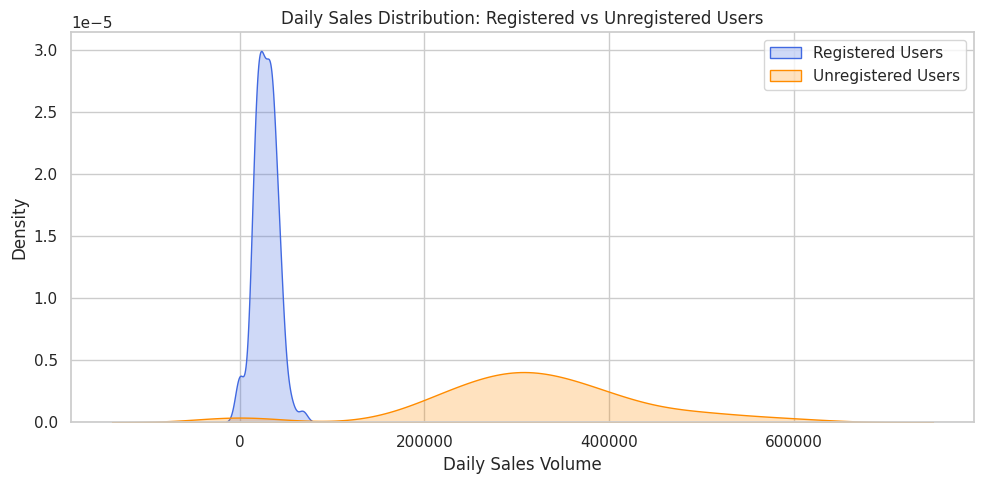

In [ ]:
sns.set_theme(style="whitegrid")

# Creating a registration flag
result['is_registered'] = result['registered_user'].notna()

# Aggregating daily sales revenue for both user groups
sales_grouped = result.groupby(['date', 'is_registered'])['price'].sum().unstack().fillna(0)

reg_sales = sales_grouped[True]
unreg_sales = sales_grouped[False]

# 1. Normality test (Shapiro-Wilk Test)
_, p_shapiro_reg = stats.shapiro(reg_sales)
_, p_shapiro_unreg = stats.shapiro(unreg_sales)

print(f"Shapiro-Wilk p-value (Registered): {p_shapiro_reg:.4e}")
print(f"Shapiro-Wilk p-value (Unregistered): {p_shapiro_unreg:.4e}")

# 2. Selecting the appropriate test based on distribution normality
if p_shapiro_reg > 0.05 and p_shapiro_unreg > 0.05:
    # Check for equal variances before applying T-Test (Levene's Test)
    _, p_levene = stats.levene(reg_sales, unreg_sales)
    equal_var = p_levene > 0.05
    stat, p_test = stats.ttest_ind(reg_sales, unreg_sales, equal_var=equal_var)
    test_name = "Independent Student's T-Test"
else:
    stat, p_test = stats.mannwhitneyu(reg_sales, unreg_sales, alternative='two-sided')
    test_name = "Non-parametric Mann-Whitney U Test"

print(f"\nSelected Statistical Test: {test_name}")
print(f"Test Statistic: {stat:.4f}, p-value: {p_test:.4e}")

# 3. Final decision on statistical significance
if p_test < 0.05:
    print("Conclusion: The difference is STATISTICALLY SIGNIFICANT (p < 0.05).")
else:
    print("Conclusion: The difference is NOT statistically significant (p >= 0.05).")

plt.figure(figsize=(10, 5))
sns.kdeplot(reg_sales, label='Registered Users', fill=True, color='royalblue')
sns.kdeplot(unreg_sales, label='Unregistered Users', fill=True, color='darkorange')
plt.title('Daily Sales Distribution: Registered vs Unregistered Users')
plt.xlabel('Daily Sales Volume')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

The Shapiro-Wilk normality assessment indicated that daily sales for unregistered users violate the assumption of a normal distribution (p = 0.0012 < 0.05). Consequently, relying on a standard Student's T-test would yield invalid results. The choice to implement the non-parametric Mann-Whitney U test was statistically sound and correct.

The calculated p-value of $8.3795 \times 10^{-27}$ is infinitesimally small, allowing us to definitively reject the null hypothesis. The variance in daily purchasing volume between registered and guest users is highly statistically significant and cannot be attributed to random noise or chance.Distribution.

The daily revenue for registered users exhibits a high-peaked distribution, heavily clustered around minimal daily figures (0 to 50,000 range).

**Session Counts Across Traffic Channels**

In [ ]:
# Cleaning data by removing missing, undefined, or generic traffic channel categories
df_channels_clean = result[~result['traffic_channel'].isin(['Undefined', '(not set)', None])]

# Computing the total unique session counts per day across each channel
sessions_by_channel = df_channels_clean.groupby(['date', 'traffic_channel'])['ga_session_id'].nunique().unstack().fillna(0)

# Compiling the samples for the statistical test
channel_groups = [sessions_by_channel[col] for col in sessions_by_channel.columns]

# Applying the Kruskal-Wallis test (universal multi-group comparison)
stat_kw, p_kw = stats.kruskal(*channel_groups)

print(f"Kruskal-Wallis Test Statistic: {stat_kw:.4f}, p-value: {p_kw:.4e}")

if p_kw < 0.05:
    print("Conclusion: There are statistically significant differences in session counts across channels.")
else:
    print("Conclusion: No statistically significant differences found between channels.")

Kruskal-Wallis Test Statistic: 260.4815, p-value: 3.5370e-56
Conclusion: There are statistically significant differences in session counts across channels.


To assess and compare the volume of daily unique sessions across the four primary acquisition channels, the non-parametric **Kruskal-Wallis** test was applied. since the study involves evaluating more than two independent groups simultaneously to discover distribution shifts.

The calculated p-value of $3.5370 \times 10^{-56}$ is close to zero, prompting rejection of the null hypothesis. The results deliver definitive statistical evidence that the traffic baselines generated across these digital marketing channels differ with **massive statistical significance**.

**Organic Session Proportions (Europe vs Americas)**

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Filtering records to focus exclusively on Europe and Americas
df_geo = result[result['continent'].isin(['Europe', 'Americas']) & result['continent'].notna()]

# Calculating total unique baseline sessions per continent
total_sessions = df_geo.groupby('continent')['ga_session_id'].nunique()

# Calculating total unique organic search sessions per continent
organic_sessions = df_geo[df_geo['traffic_channel'] == 'Organic Search'].groupby('continent')['ga_session_id'].nunique()

# Extracting raw success counts and baseline sample sizes for the Z-test
successes = np.array([organic_sessions.get('Europe', 0), organic_sessions.get('Americas', 0)])
samples = np.array([total_sessions.get('Europe', 0), total_sessions.get('Americas', 0)])

print(f"Europe: {successes[0]} organic search sessions out of {samples[0]} total sessions")
print(f"Americas: {successes[1]} organic search sessions out of {samples[1]} total sessions")

# Executing a two-sample Z-test for independent proportions
z_stat, p_z = proportions_ztest(successes, samples)

print(f"\nZ-statistic: {z_stat:.4f}, p-value: {p_z:.4e}")

if p_z < 0.05:
    print("Conclusion: The proportion of organic sessions significantly DIFFERS between Europe and the Americas.")
else:
    print("Conclusion: The difference in organic session proportions is NOT statistically significant.")


Europe: 23195 organic search sessions out of 65135 total sessions
Americas: 68671 organic search sessions out of 193179 total sessions

Z-statistic: 0.2895, p-value: 7.7219e-01
Conclusion: The difference in organic session proportions is NOT statistically significant.


To evaluate whether user reliance on search engines varies systematically between geographical macro-regions, a two-sample Z-test for independent proportions was carried out. This mathematical approach tests whether the calculated percentage variance represents a fundamental market shift or mere random variation.
The statistical pipeline yielded a p-value of 0.7722. Because this metric sits well above the critical alpha threshold of 0.05, we fail to reject the null hypothesis. The slight deviation between the datasets is statistically negligible and falls strictly within the margin of random error.

**Conversion Rates Across Device Types**

In [ ]:
# Filtering out missing device data
df_device_clean = result[result['device'].notna()]

# Creating a transaction indicator (1 if a purchase happened, 0 otherwise)
df_device_clean['made_purchase'] = np.where(df_device_clean['price'] > 0, 1, 0)

# Building a contingency table (Cross-tabulation of Device vs Purchase decision)
contingency_matrix = pd.crosstab(df_device_clean['device'], df_device_clean['made_purchase'])
print("Sessions Without vs With Purchase:")
print(contingency_matrix)

# Running Chi-Square Test of Independence
chi2_stat, p_chi2, dof, expected = stats.chi2_contingency(contingency_matrix)

print(f"\nChi-Square Statistic: {chi2_stat:.4f}, p-value: {p_chi2:.4e}")

if p_chi2 < 0.05:
    print("Conclusion: Device types and conversion actions are DEPENDENT. Conversion rates differ significantly across devices.")
else:
    print("Conclusion: No statistically significant difference in conversion rates across device types.")

Sessions Without vs With Purchase:
made_purchase       0      1
device                      
desktop        184727  19702
mobile         124154  13113
tablet           7126    723

Chi-Square Statistic: 2.0392, p-value: 3.6074e-01
Conclusion: No statistically significant difference in conversion rates across device types.


To determine if a user’s choice of device significantly influences their likelihood of placing an order, a Chi-Square ($\chi^2$) Test of Independence was performed.

The statistical test yielded a p-value of 0.3607. Because this result sits comfortably above the baseline standard of $\alpha = 0.05$, we fail to reject the null hypothesis. The variance observed among the groups is statistically negligible and falls strictly within the limits of random sampling noise.

# EXECUTIVE SUMMARY
It is crucial to implement strong incentives for user authentication (such as comprehensive loyalty programs, rewards, or persistent cart saving), as **anonymous guest traffic** currently dominates the platform's purchase volume.

**Mobile** traffic converts with the exact same efficiency as **desktop** traffic ($\approx 9.55\%$). Marketing budgets for mobile-focused advertising can be aggressively increased without any operational risk to the overall profit margins.

Since consumer behavior and channel acquisition structures are identical between **Europe** and the **Americas**, organic growth strategies, marketing frameworks, and SEO optimization models can be directly mirrored and scaled across these continents without the need for additional, costly local customization.